<a href="https://colab.research.google.com/github/adilsaleem007/Python-Basics-Assignment/blob/main/CaseStudy2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#importing relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings("ignore")

In [3]:
#load dataset
df = pd.read_csv("/content/adult_dataset.csv")
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [4]:
#data information and description
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [5]:
#data preprocessing
df.replace("?", np.nan, inplace=True) #replacing ?

In [6]:
#handling missing values
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [7]:
#missing numerical
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [8]:
#handling outliers
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] > upper, upper, df[col])
    df[col] = np.where(df[col] < lower, lower, df[col])

In [9]:
#encoding categorical values
df = pd.get_dummies(df, drop_first=True)

In [10]:
#scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [11]:
#drop column income(given)
df = df.drop("income", axis=1)
#executed this code before and dropped,not running again as it will show error

KeyError: "['income'] not found in axis"

In [12]:
#checking after preprocessing
df.isnull().sum()

,0
age,0
fnlwgt,0
education-num,0
capital-gain,0
capital-loss,0
...,...
native-country_Vietnam,0
native-country_Yugoslavia,0
income_<=50K.,0
income_>50K,0


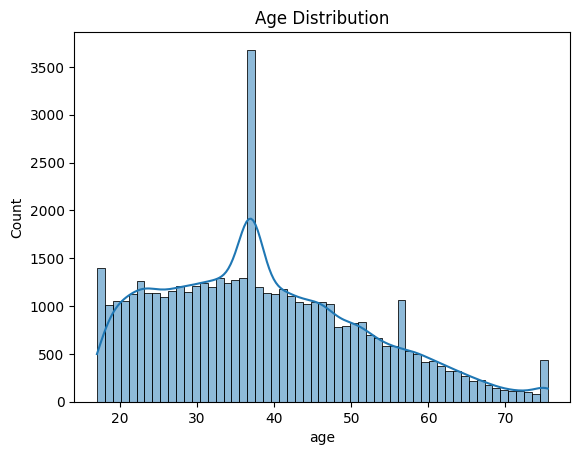

In [13]:
#visualization of Age Distribution
sns.histplot(df["age"], kde=True)
plt.title("Age Distribution")
plt.show()

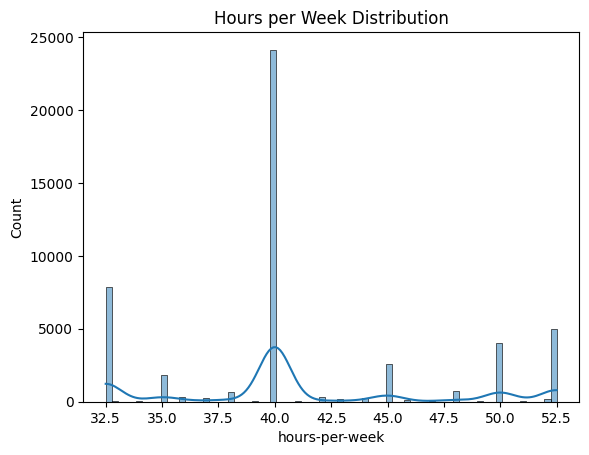

In [14]:
#visualization of Hours per Week
sns.histplot(df["hours-per-week"], kde=True)
plt.title("Hours per Week Distribution")
plt.show()

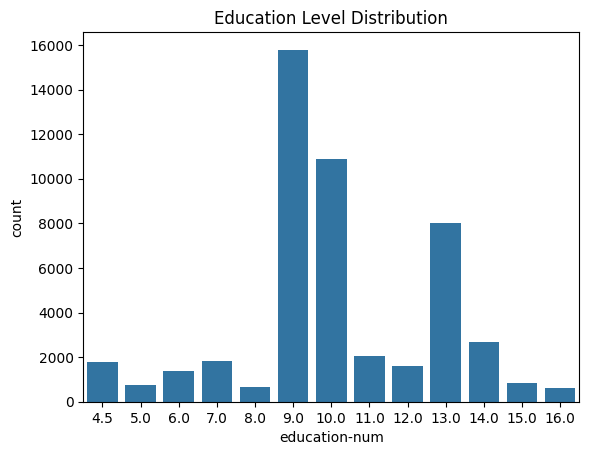

In [15]:
#visualization of Education Level
sns.countplot(x="education-num", data=df)
plt.title("Education Level Distribution")
plt.show()

In [16]:
#checking skewness
print("Capital Gain Skewness:", df["capital-gain"].skew())
print("Capital Loss Skewness:", df["capital-loss"].skew())

Capital Gain Skewness: 0.0
Capital Loss Skewness: 0.0


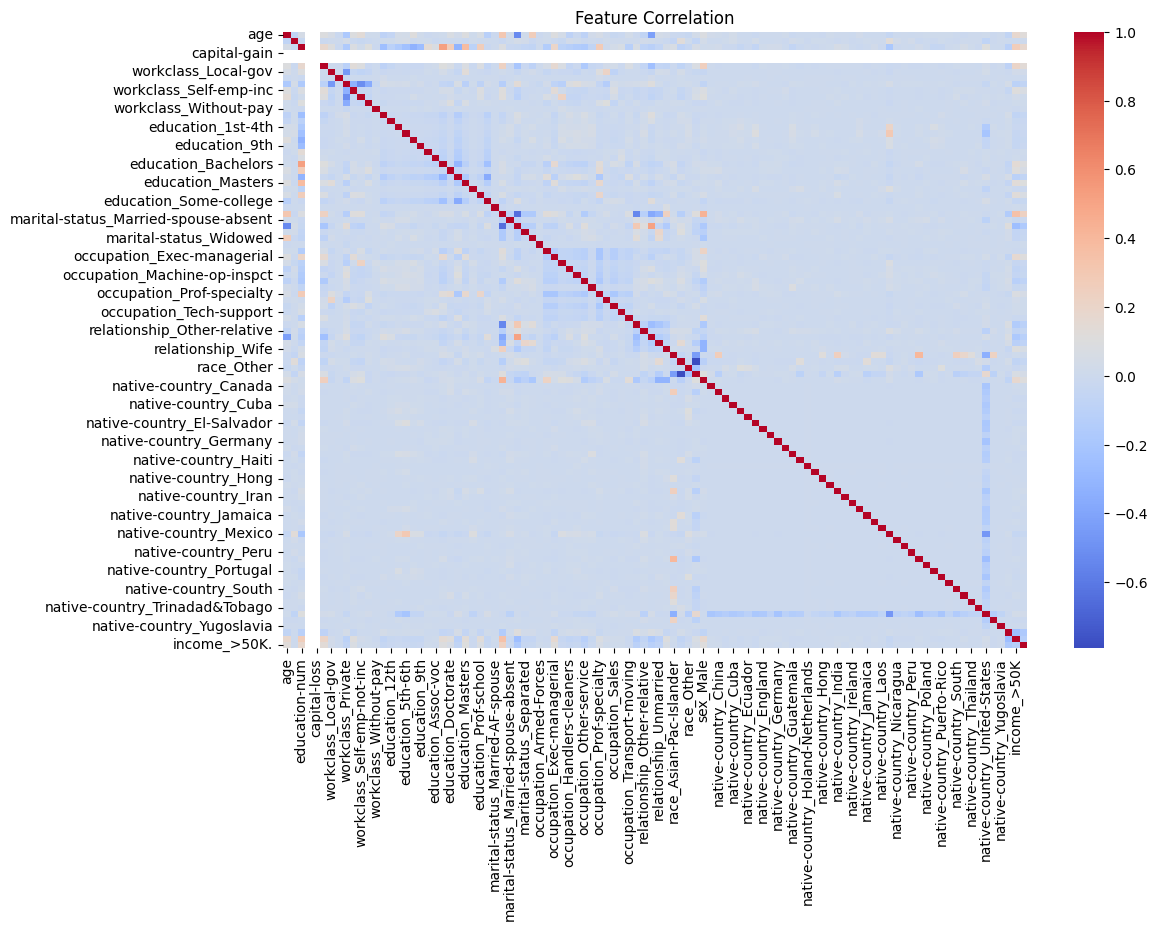

In [17]:
#Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

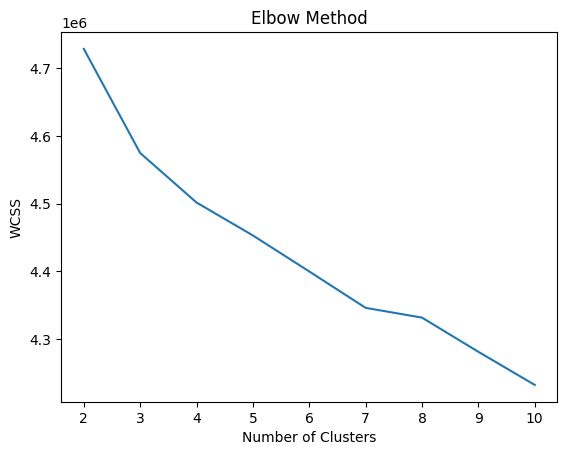

In [18]:
#clustering by K-Means Clustering
wcss = []

for i in range(2,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [25]:
#calculating silhouette_scores
silhouette_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.09459677412727914
K=3, Silhouette Score=0.050688746223721645
K=4, Silhouette Score=0.02755218991037001
K=5, Silhouette Score=0.030272710849301082
K=6, Silhouette Score=0.01861244136713505
K=7, Silhouette Score=0.02284368271645418
K=8, Silhouette Score=0.04890029392906001
K=9, Silhouette Score=0.050451978086422884
K=10, Silhouette Score=0.050415551407308905


In [26]:
# Final KMeans with optimal K = 2
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

df["KMeans_Cluster"] = kmeans_labels

print("Final Silhouette Score:", silhouette_score(scaled_data, kmeans_labels))



Final Silhouette Score: 0.09459677412727914


In [ ]:
#To avoid memory overload, clustering and dendrogram generation were performed on a representative sample of the dataset.
agg = AgglomerativeClustering(n_clusters=2)
agg_labels = agg.fit_predict(scaled_data)

df["Agglomerative_Cluster"] = agg_labels

print("Silhouette Score (Agglomerative):",
      silhouette_score(scaled_data, agg_labels))

To avoid memory overload, clustering and dendrogram generation were performed on a representative sample of the dataset.

In [19]:
# Take manageable sample (2000 rows)
sample_size = 2000
sample_data = scaled_data[:sample_size]

from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=2)
agg_labels_sample = agg.fit_predict(sample_data)

print("Agglomerative clustering done on sample.")

Agglomerative clustering done on sample.


In [20]:
print("Silhouette Score (Agglomerative - Sample):",
      silhouette_score(sample_data, agg_labels_sample))

Silhouette Score (Agglomerative - Sample): 0.8038833338414734


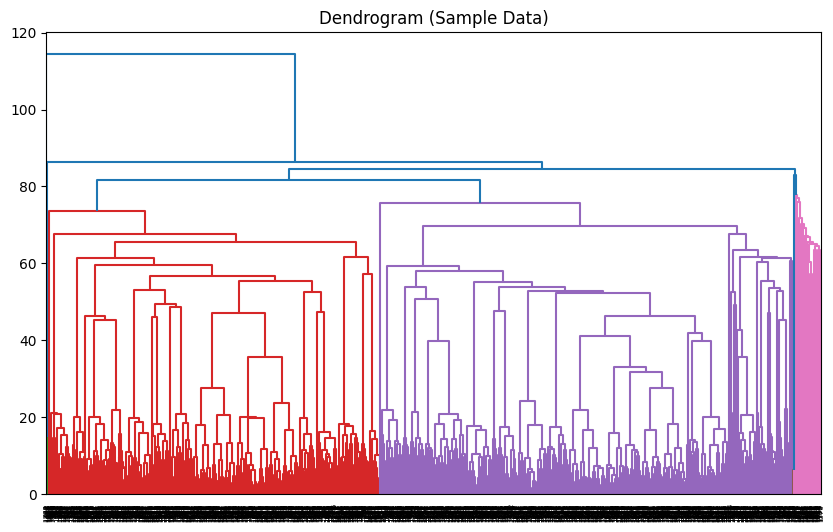

In [21]:
#dendrogram for sample data
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(sample_data, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Dendrogram (Sample Data)")
plt.show()

In [23]:
#PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Captured:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.03818857 0.02699922]
Total Variance Captured: 0.06518778871519977


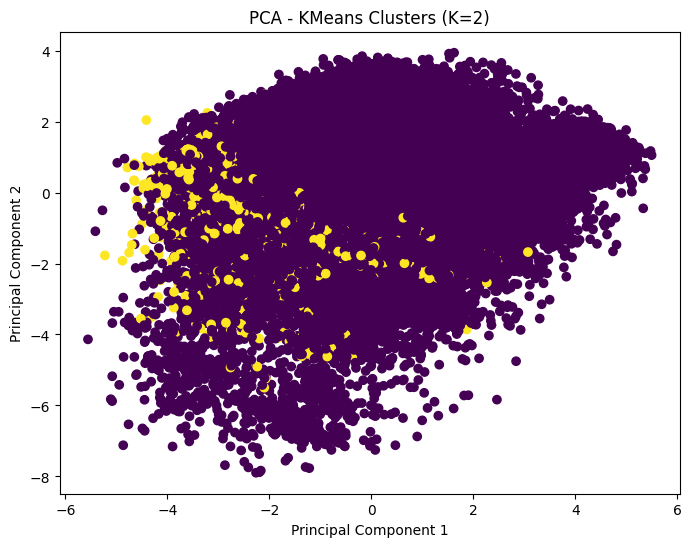

In [27]:
plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=kmeans_labels)
plt.title("PCA - KMeans Clusters (K=2)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

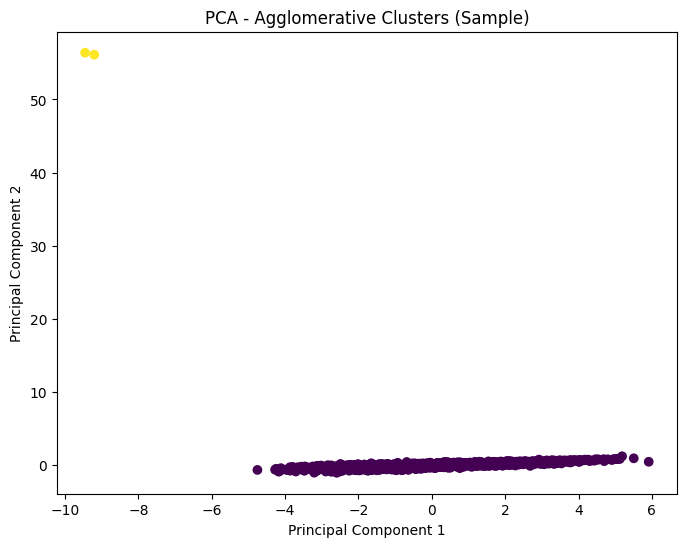

In [28]:
# PCA for sample
pca_sample = PCA(n_components=2)
pca_sample_data = pca_sample.fit_transform(sample_data)

plt.figure(figsize=(8,6))
plt.scatter(pca_sample_data[:,0],
            pca_sample_data[:,1],
            c=agg_labels_sample)
plt.title("PCA - Agglomerative Clusters (Sample)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()